# ADS-505 Team 09 — Complete Olist Exploratory Data Analysis

**Student:** Bereket Tarekegn  
**Dataset:** Olist Brazilian E-Commerce Public Dataset  
**Course:** ADS-505 Applied Data Science for Business

## Purpose

This notebook consolidates the EDA questions discussed by the team so far and is designed to help us choose a **specific predictive business problem without forcing a target too early**.

The analysis covers:

1. Data quality, keys, missingness, duplicates, and relational structure.
2. Order, item, payment, product, customer, seller, and review behavior.
3. Delivery and fulfillment performance.
4. The multiple-review issue before any review aggregation.
5. Repeat-customer feasibility.
6. A seller-level performance profile combining **commercial value, customer experience, and fulfillment**.
7. Whether sellers show enough historical consistency to support future seller prioritization.
8. Seller geography, product mix, concentration, and operational risk.
9. Candidate business problems and possible predictive targets.
10. Prediction-time / leakage considerations.
11. A final EDA decision framework for the team.

### Main business question under investigation

> **Can Olist identify sellers that provide both strong commercial value and strong customer experience, and use historical marketplace data to prioritize seller relationships, support, or growth opportunities?**

We will also keep other candidate applications visible until the EDA shows which one is most defensible.

In [2]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Look for the 9 Olist CSV files in the current folder or an 'olist' subfolder.
required_files = {
    "customers": "olist_customers_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

candidate_dirs = [Path("."), Path("./olist"), Path("/mnt/data/olist")]
DATA_DIR = None
for folder in candidate_dirs:
    if all((folder / f).exists() for f in required_files.values()):
        DATA_DIR = folder
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find all 9 Olist CSV files. Put this notebook in the same folder "
        "as the CSV files or place them in a subfolder named 'olist'."
    )

print("Using data folder:", DATA_DIR.resolve())

Using data folder: C:\Users\bezaa\OneDrive\Desktop\USD\ADS 505\Project\olis


## 1. Load all nine source tables

In [4]:
data = {}
for name, filename in required_files.items():
    data[name] = pd.read_csv(DATA_DIR / filename)

customers = data["customers"]
geolocation = data["geolocation"]
order_items = data["order_items"]
payments = data["payments"]
reviews = data["reviews"]
orders = data["orders"]
products = data["products"]
sellers = data["sellers"]
category_translation = data["category_translation"]

for name, df in data.items():
    print(f"{name:22s} rows={len(df):,} columns={df.shape[1]}")

customers              rows=99,441 columns=5
geolocation            rows=1,000,163 columns=5
order_items            rows=112,650 columns=7
payments               rows=103,886 columns=5
reviews                rows=99,224 columns=7
orders                 rows=99,441 columns=8
products               rows=32,951 columns=9
sellers                rows=3,095 columns=4
category_translation   rows=71 columns=2


## 2. Structural and data-quality audit

Before joining anything, we need to know which tables are one-row-per-entity and which tables are one-to-many.

A major risk in Olist is **many-to-many row multiplication**. `order_items`, `payments`, and `reviews` may all contain multiple rows for the same order, so they should be summarized separately before being combined at order level.

In [6]:
inventory = []
for name, df in data.items():
    inventory.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_full_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum())
    })

inventory_df = pd.DataFrame(inventory).sort_values("rows", ascending=False)
inventory_df

,table,rows,columns,duplicate_full_rows,missing_cells
1,geolocation,1000163,5,261831,0
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
0,customers,99441,5,0,0
5,orders,99441,8,0,4908
4,reviews,99224,7,0,145903
6,products,32951,9,0,2448
7,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [7]:
missing_rows = []
for name, df in data.items():
    for col in df.columns:
        n = int(df[col].isna().sum())
        if n:
            missing_rows.append({
                "table": name,
                "column": col,
                "missing": n,
                "percent_missing": 100 * n / len(df)
            })

missing_df = pd.DataFrame(missing_rows).sort_values(
    ["percent_missing", "missing"], ascending=False
)
missing_df.head(30)

,table,column,missing,percent_missing
0,reviews,review_comment_title,87656,88.342
1,reviews,review_comment_message,58247,58.703
4,orders,order_delivered_customer_date,2965,2.982
5,products,product_category_name,610,1.851
6,products,product_name_lenght,610,1.851
7,products,product_description_lenght,610,1.851
8,products,product_photos_qty,610,1.851
3,orders,order_delivered_carrier_date,1783,1.793
2,orders,order_approved_at,160,0.161
9,products,product_weight_g,2,0.006


### Candidate keys and order-table cardinality

In [9]:
key_checks = pd.DataFrame([
    ["orders", "order_id", orders["order_id"].nunique(), len(orders)],
    ["customers", "customer_id", customers["customer_id"].nunique(), len(customers)],
    ["products", "product_id", products["product_id"].nunique(), len(products)],
    ["sellers", "seller_id", sellers["seller_id"].nunique(), len(sellers)],
    ["reviews", "review_id", reviews["review_id"].nunique(), len(reviews)],
], columns=["table", "candidate_key", "unique_values", "rows"])

key_checks["unique_per_row"] = key_checks["unique_values"] == key_checks["rows"]
key_checks

,table,candidate_key,unique_values,rows,unique_per_row
0,orders,order_id,99441,99441,True
1,customers,customer_id,99441,99441,True
2,products,product_id,32951,32951,True
3,sellers,seller_id,3095,3095,True
4,reviews,review_id,98410,99224,False


In [10]:
order_cardinality = pd.DataFrame({
    "table": ["orders", "order_items", "payments", "reviews"],
    "rows": [len(orders), len(order_items), len(payments), len(reviews)],
    "unique_order_ids": [
        orders["order_id"].nunique(),
        order_items["order_id"].nunique(),
        payments["order_id"].nunique(),
        reviews["order_id"].nunique()
    ]
})
order_cardinality["rows_per_order"] = (
    order_cardinality["rows"] / order_cardinality["unique_order_ids"]
)
order_cardinality

,table,rows,unique_order_ids,rows_per_order
0,orders,99441,99441,1.000
1,order_items,112650,98666,1.142
2,payments,103886,99440,1.045
3,reviews,99224,98673,1.006


## 3. Date preparation and order lifecycle measures

These timestamps describe different stages of the lifecycle. They should **not all be treated as predictors** for the same model. Some occur only after the outcome has already happened.

For EDA, however, they are useful for understanding the business process.

In [12]:
orders_dt = orders.copy()

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders_dt[col] = pd.to_datetime(orders_dt[col], errors="coerce")

orders_dt["purchase_to_approval_hours"] = (
    orders_dt["order_approved_at"] - orders_dt["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders_dt["purchase_to_carrier_days"] = (
    orders_dt["order_delivered_carrier_date"] - orders_dt["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_dt["purchase_to_delivery_days"] = (
    orders_dt["order_delivered_customer_date"] - orders_dt["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_dt["delivery_vs_estimate_days"] = (
    orders_dt["order_delivered_customer_date"] - orders_dt["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_dt["promised_window_days"] = (
    orders_dt["order_estimated_delivery_date"] - orders_dt["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_dt["late_delivery"] = np.where(
    orders_dt["order_delivered_customer_date"].notna(),
    orders_dt["delivery_vs_estimate_days"] > 0,
    np.nan
)

orders_dt["purchase_year_month"] = orders_dt["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders_dt["purchase_weekday"] = orders_dt["order_purchase_timestamp"].dt.day_name()
orders_dt["purchase_hour"] = orders_dt["order_purchase_timestamp"].dt.hour

orders_dt[[
    "purchase_to_approval_hours",
    "purchase_to_carrier_days",
    "purchase_to_delivery_days",
    "delivery_vs_estimate_days",
    "promised_window_days"
]].describe()

,purchase_to_approval_hours,purchase_to_carrier_days,purchase_to_delivery_days,delivery_vs_estimate_days,promised_window_days
count,"99,281.000","97,658.000","96,476.000","96,476.000","99,441.000"
mean,10.419,3.234,12.559,-11.179,23.768
std,26.038,3.612,9.547,10.186,8.832
min,0.000,-171.212,0.533,-146.016,1.649
25%,0.215,1.129,6.766,-16.244,18.332
50%,0.343,2.205,10.218,-11.949,23.240
75%,14.581,4.072,15.720,-6.390,28.425
max,"4,509.181",125.776,209.629,188.975,155.135


In [13]:
status_summary = orders_dt["order_status"].value_counts(dropna=False).to_frame("orders")
status_summary["percent"] = 100 * status_summary["orders"] / len(orders_dt)
status_summary

,orders,percent
order_status,,
delivered,96478,97.020
shipped,1107,1.113
canceled,625,0.629
unavailable,609,0.612
invoiced,314,0.316
processing,301,0.303
created,5,0.005
approved,2,0.002


## 4. Order-item summary and seller shipping-deadline behavior

In [15]:
items = order_items.copy()
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")

item_order_summary = (
    items.groupby("order_id")
    .agg(
        item_lines=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_sellers=("seller_id", "nunique"),
        merchandise_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        first_shipping_limit=("shipping_limit_date", "min"),
        last_shipping_limit=("shipping_limit_date", "max")
    )
    .reset_index()
)

item_order_summary["order_value_including_freight"] = (
    item_order_summary["merchandise_value"] + item_order_summary["freight_value"]
)
item_order_summary["freight_share"] = (
    item_order_summary["freight_value"] /
    item_order_summary["order_value_including_freight"].replace(0, np.nan)
)

item_order_summary.describe()

,item_lines,unique_products,unique_sellers,merchandise_value,freight_value,first_shipping_limit,last_shipping_limit,order_value_including_freight,freight_share
count,"98,666.000","98,666.000","98,666.000","98,666.000","98,666.000",98666,98666,"98,666.000","98,666.000"
mean,1.142,1.038,1.014,137.754,22.824,2018-01-07 12:34:40.613726976,2018-01-07 12:54:18.369002752,160.578,0.209
min,1.000,1.000,1.000,0.850,0.000,2016-09-19 00:15:34,2016-09-19 00:15:34,9.590,0.000
25%,1.000,1.000,1.000,45.900,13.850,2017-09-20 02:55:30,2017-09-20 02:55:30,61.980,0.117
50%,1.000,1.000,1.000,86.900,17.170,2018-01-26 13:52:23.500000,2018-01-26 13:52:23.500000,105.290,0.183
75%,1.000,1.000,1.000,149.900,24.040,2018-05-10 15:10:22,2018-05-10 15:14:05.249999872,176.870,0.275
max,21.000,8.000,5.000,"13,440.000","1,794.960",2020-04-09 22:35:08,2020-04-09 22:35:08,"13,664.080",0.955
std,0.538,0.226,0.122,210.645,21.651,NaN,NaN,220.466,0.126


In [16]:
# Join carrier handoff to item rows so we can compare actual handoff with each seller/item deadline.
item_fulfillment = items.merge(
    orders_dt[[
        "order_id", "order_purchase_timestamp", "order_delivered_carrier_date",
        "order_delivered_customer_date", "order_estimated_delivery_date",
        "late_delivery", "delivery_vs_estimate_days"
    ]],
    on="order_id",
    how="left"
)

item_fulfillment["seller_deadline_miss"] = np.where(
    item_fulfillment["order_delivered_carrier_date"].notna() &
    item_fulfillment["shipping_limit_date"].notna(),
    item_fulfillment["order_delivered_carrier_date"] > item_fulfillment["shipping_limit_date"],
    np.nan
)

item_fulfillment["carrier_vs_shipping_limit_days"] = (
    item_fulfillment["order_delivered_carrier_date"] -
    item_fulfillment["shipping_limit_date"]
).dt.total_seconds() / 86400

deadline_summary = (
    item_fulfillment.dropna(subset=["seller_deadline_miss", "late_delivery"])
    .groupby("seller_deadline_miss")
    .agg(
        item_lines=("order_id", "size"),
        unique_orders=("order_id", "nunique"),
        late_delivery_rate=("late_delivery", "mean"),
        avg_delivery_vs_estimate=("delivery_vs_estimate_days", "mean")
    )
)
deadline_summary

,item_lines,unique_orders,late_delivery_rate,avg_delivery_vs_estimate
seller_deadline_miss,,,,
0.000,99924,87762,0.062,-11.945
1.000,10271,8725,0.241,-5.381


### Interpretation checkpoint

This section helps separate two ideas:

- **Seller fulfillment behavior:** whether the order reaches the carrier by the seller's shipping limit.
- **Final customer delivery:** whether the customer receives the order by the estimated delivery date.

If missing the seller deadline is strongly associated with late customer delivery, seller performance may be important. However, a simple deadline reminder may not require machine learning. That is why we also investigate seller-level performance and future seller value below.

## 5. Product and category structure

In [19]:
products_en = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

product_items = items.merge(
    products_en,
    on="product_id",
    how="left"
)

category_summary = (
    product_items.groupby("product_category_name_english", dropna=False)
    .agg(
        item_lines=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        sellers=("seller_id", "nunique"),
        merchandise_value=("price", "sum"),
        freight_value=("freight_value", "sum"),
        avg_price=("price", "mean"),
        avg_weight_g=("product_weight_g", "mean")
    )
    .sort_values("merchandise_value", ascending=False)
)

category_summary.head(20)

,item_lines,orders,sellers,merchandise_value,freight_value,avg_price,avg_weight_g
product_category_name_english,,,,,,,
health_beauty,9670,8836,492,"1,258,681.340","182,566.730",130.164,"1,048.766"
watches_gifts,5991,5624,101,"1,205,005.680","100,535.930",201.136,580.977
bed_bath_table,11115,9417,196,"1,036,988.680","204,693.040",93.296,"2,116.753"
sports_leisure,8641,7720,481,"988,048.970","168,607.510",114.344,"1,743.062"
computers_accessories,7827,6689,287,"911,954.320","147,318.080",116.514,902.509
furniture_decor,8334,6449,370,"729,762.490","172,749.300",87.564,"2,653.129"
cool_stuff,3796,3632,267,"635,290.850","84,039.100",167.358,"2,548.971"
housewares,6964,5884,468,"632,248.660","146,149.110",90.788,"3,214.588"
auto,4235,3897,383,"592,720.110","92,664.210",139.958,"2,594.148"


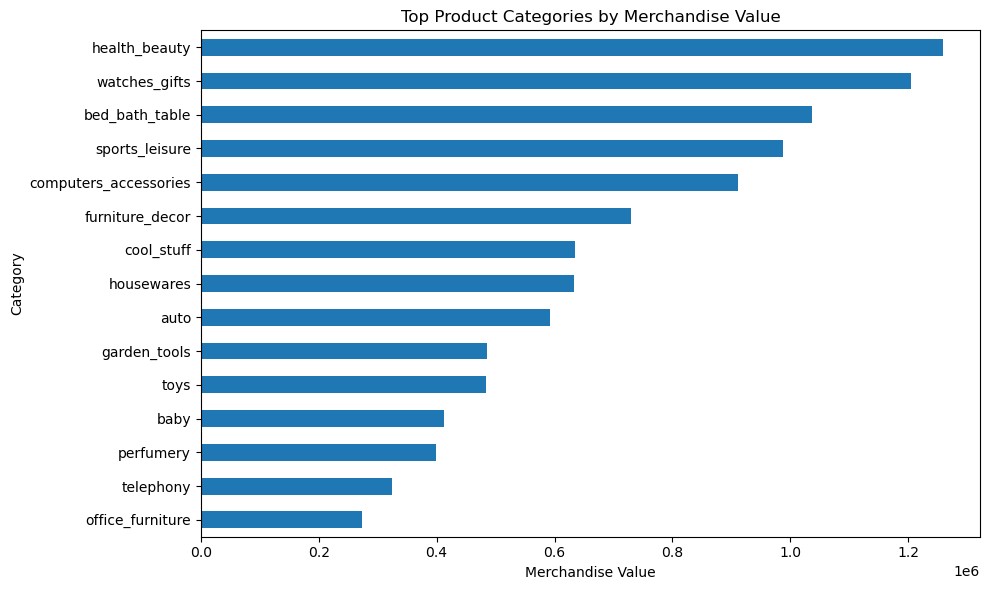

In [20]:
top_cat_plot = category_summary.head(15).sort_values("merchandise_value")
plt.figure(figsize=(10, 6))
top_cat_plot["merchandise_value"].plot(kind="barh")
plt.title("Top Product Categories by Merchandise Value")
plt.xlabel("Merchandise Value")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 6. Payment behavior

In [22]:
payment_summary = (
    payments.groupby("order_id")
    .agg(
        payment_records=("payment_sequential", "count"),
        payment_value=("payment_value", "sum"),
        max_installments=("payment_installments", "max"),
        payment_types=("payment_type", lambda x: "|".join(sorted(set(x.astype(str)))))
    )
    .reset_index()
)

payments["payment_type"].value_counts(dropna=False)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

## 7. Review-level EDA — do not aggregate blindly

The team specifically discussed whether multiple reviews for an order should simply be averaged.

We first preserve review chronology and determine:

- how common multiple reviews are,
- whether the scores actually change,
- whether repeated reviews use distinct review IDs,
- whether score changes appear related to delivery or operational performance.

In [24]:
reviews_dt = reviews.copy()
reviews_dt["review_creation_date"] = pd.to_datetime(
    reviews_dt["review_creation_date"], errors="coerce"
)
reviews_dt["review_answer_timestamp"] = pd.to_datetime(
    reviews_dt["review_answer_timestamp"], errors="coerce"
)

review_count_per_order = reviews_dt.groupby("order_id").size().rename("review_record_count")
review_count_per_order.value_counts().sort_index()

review_record_count
1    98126
2      543
3        4
Name: count, dtype: int64

In [25]:
multi_review_orders = review_count_per_order[review_count_per_order > 1].index
multi_reviews = (
    reviews_dt[reviews_dt["order_id"].isin(multi_review_orders)]
    .sort_values(["order_id", "review_creation_date", "review_answer_timestamp"])
    .copy()
)

multi_review_profile = (
    multi_reviews.groupby("order_id")
    .agg(
        review_records=("review_id", "size"),
        unique_review_ids=("review_id", "nunique"),
        unique_scores=("review_score", "nunique"),
        first_review_date=("review_creation_date", "min"),
        last_review_date=("review_creation_date", "max")
    )
)

multi_review_profile["review_span_days"] = (
    multi_review_profile["last_review_date"] -
    multi_review_profile["first_review_date"]
).dt.days

print("Orders with multiple review records:", len(multi_review_profile))
print("Percent of reviewed orders:",
      f"{len(multi_review_profile) / reviews_dt['order_id'].nunique():.2%}")
print("Multiple-review orders with score changes:",
      int((multi_review_profile['unique_scores'] > 1).sum()))
print("Multiple-review orders with multiple distinct review IDs:",
      int((multi_review_profile['unique_review_ids'] > 1).sum()))

multi_review_profile.describe()

Orders with multiple review records: 547
Percent of reviewed orders: 0.55%
Multiple-review orders with score changes: 202
Multiple-review orders with multiple distinct review IDs: 547


,review_records,unique_review_ids,unique_scores,first_review_date,last_review_date,review_span_days
count,547.000,547.000,547.000,547,547,547.000
mean,2.007,2.007,1.369,2017-11-15 00:23:48.153564928,2017-11-20 04:31:15.685557504,5.172
min,2.000,2.000,1.000,2016-10-27 00:00:00,2016-10-29 00:00:00,0.000
25%,2.000,2.000,1.000,2017-08-04 00:00:00,2017-08-10 00:00:00,0.000
50%,2.000,2.000,1.000,2017-12-01 00:00:00,2017-12-06 00:00:00,3.000
75%,2.000,2.000,2.000,2018-03-03 00:00:00,2018-03-10 00:00:00,7.000
max,3.000,3.000,2.000,2018-08-29 00:00:00,2018-08-29 00:00:00,106.000
std,0.085,0.085,0.483,NaN,NaN,9.177


In [26]:
review_sequence = reviews_dt.sort_values(
    ["order_id", "review_creation_date", "review_answer_timestamp"]
).copy()

review_sequence["review_sequence_number"] = (
    review_sequence.groupby("order_id").cumcount() + 1
)

review_change_summary = (
    review_sequence.groupby("order_id")
    .agg(
        review_count=("review_score", "size"),
        first_review_score=("review_score", "first"),
        last_review_score=("review_score", "last"),
        mean_review_score=("review_score", "mean"),
        min_review_score=("review_score", "min"),
        max_review_score=("review_score", "max"),
        first_review_date=("review_creation_date", "first"),
        last_review_date=("review_creation_date", "last")
    )
    .reset_index()
)

review_change_summary["score_change"] = (
    review_change_summary["last_review_score"] -
    review_change_summary["first_review_score"]
)

review_change_summary["score_change_direction"] = np.select(
    [
        review_change_summary["score_change"] > 0,
        review_change_summary["score_change"] < 0,
        review_change_summary["score_change"] == 0,
    ],
    ["Improved", "Declined", "No change"],
    default="Unknown"
)

review_change_summary.loc[
    review_change_summary["review_count"] > 1,
    "score_change_direction"
].value_counts()

score_change_direction
No change    345
Declined     119
Improved      83
Name: count, dtype: int64

### Review aggregation decision

For the main order-level and seller-level EDA below, we retain:

- `mean_review_score` for broad descriptive comparisons,
- `last_review_score` as the latest recorded customer assessment,
- `review_count` and `score_change` so the repeated-review information is not lost.

The notebook does **not** overwrite the raw review table.

## 8. Build one-row-per-order analytical table

In [29]:
order_analysis = (
    orders_dt
    .merge(customers, on="customer_id", how="left")
    .merge(item_order_summary, on="order_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(review_change_summary, on="order_id", how="left")
)

assert len(order_analysis) == order_analysis["order_id"].nunique()

print("Rows:", len(order_analysis))
print("Unique orders:", order_analysis["order_id"].nunique())
order_analysis.head()

Rows: 99441
Unique orders: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_to_approval_hours,purchase_to_carrier_days,purchase_to_delivery_days,delivery_vs_estimate_days,promised_window_days,late_delivery,purchase_year_month,purchase_weekday,purchase_hour,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_lines,unique_products,unique_sellers,merchandise_value,freight_value,first_shipping_limit,last_shipping_limit,order_value_including_freight,freight_share,payment_records,payment_value,max_installments,payment_types,review_count,first_review_score,last_review_score,mean_review_score,min_review_score,max_review_score,first_review_date,last_review_date,score_change,score_change_direction
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178,2.374,8.437,-7.107,15.544,0.000,2017-10,Monday,10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.000,1.000,1.000,29.990,8.720,2017-10-06 11:07:15,2017-10-06 11:07:15,38.710,0.225,3.000,38.710,1.000,credit_card|voucher,1.000,4.000,4.000,4.000,4.000,4.000,2017-10-11,2017-10-11,0.000,No change
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.714,1.743,13.782,-5.356,19.138,0.000,2018-07,Tuesday,20,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.000,1.000,1.000,118.700,22.760,2018-07-30 03:24:27,2018-07-30 03:24:27,141.460,0.161,1.000,141.460,1.000,boleto,1.000,4.000,4.000,4.000,4.000,4.000,2018-08-08,2018-08-08,0.000,No change
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276,0.216,9.394,-17.245,26.640,0.000,2018-08,Wednesday,8,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.000,1.000,1.000,159.900,19.220,2018-08-13 08:55:23,2018-08-13 08:55:23,179.120,0.107,1.000,179.120,3.000,credit_card,1.000,5.000,5.000,5.000,5.000,5.000,2018-08-18,2018-08-18,0.000,No change
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298,3.758,13.209,-12.980,26.189,0.000,2017-11,Saturday,19,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.000,1.000,1.000,45.000,27.200,2017-11-23 19:45:59,2017-11-23 19:45:59,72.200,0.377,1.000,72.200,1.000,credit_card,1.000,5.000,5.000,5.000,5.000,5.000,2017-12-03,2017-12-03,0.000,No change
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.031,0.936,2.874,-9.238,12.112,0.000,2018-02,Tuesday,21,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.000,1.000,1.000,19.900,8.720,2018-02-19 20:31:37,2018-02-19 20:31:37,28.620,0.305,1.000,28.620,1.000,credit_card,1.000,5.000,5.000,5.000,5.000,5.000,2018-02-17,2018-02-17,0.000,No change


## 9. Delivery performance and customer experience

In [31]:
delivered_reviewed = order_analysis[
    order_analysis["order_status"].eq("delivered") &
    order_analysis["order_delivered_customer_date"].notna() &
    order_analysis["mean_review_score"].notna()
].copy()

review_late = (
    delivered_reviewed.groupby("late_delivery")
    .agg(
        orders=("order_id", "nunique"),
        mean_review=("mean_review_score", "mean"),
        median_review=("mean_review_score", "median"),
        mean_delivery_days=("purchase_to_delivery_days", "mean")
    )
)
review_late

,orders,mean_review,median_review,mean_delivery_days
late_delivery,,,,
0.000,88163,4.294,5.000,10.878
1.000,7661,2.567,2.000,31.379


In [32]:
bins = [-np.inf, -7, -1, 0, 3, 7, 14, np.inf]
labels = [
    "7+ days early",
    "1-6 days early",
    "On estimated date",
    "1-3 days late",
    "4-7 days late",
    "8-14 days late",
    "15+ days late"
]

order_analysis["delivery_timing_band"] = pd.cut(
    order_analysis["delivery_vs_estimate_days"],
    bins=bins,
    labels=labels
)

timing_review = (
    order_analysis.groupby("delivery_timing_band", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        mean_review=("mean_review_score", "mean")
    )
)
timing_review

,orders,mean_review
delivery_timing_band,,
7+ days early,71308,4.317
1-6 days early,15879,4.205
On estimated date,1462,4.158
1-3 days late,2662,3.767
4-7 days late,1819,2.317
8-14 days late,1791,1.746
15+ days late,1555,1.711


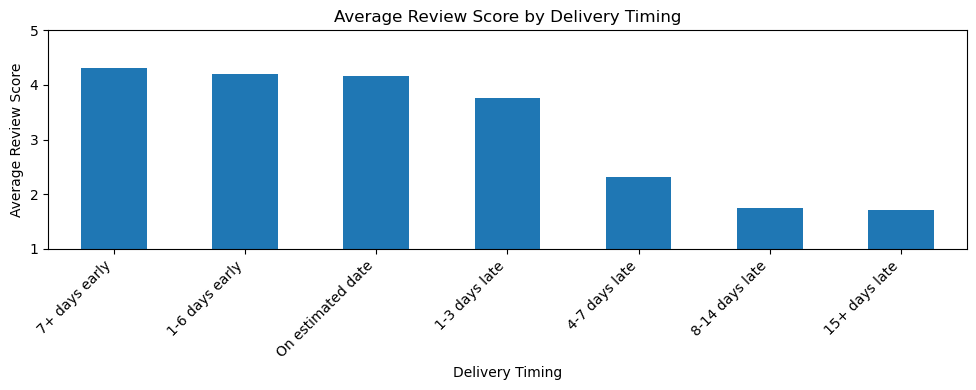

In [33]:
plt.figure(figsize=(10, 4))
timing_review["mean_review"].plot(kind="bar")
plt.title("Average Review Score by Delivery Timing")
plt.xlabel("Delivery Timing")
plt.ylabel("Average Review Score")
plt.ylim(1, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Repeat-customer feasibility

A possible project direction was customer retention / repeat purchasing. We need to check whether the dataset contains enough repeated customer history for that to be a strong modeling problem.

`customer_id` is order-specific. `customer_unique_id` is the identifier needed to recognize the same customer across different orders.

In [35]:
customer_order_counts = (
    orders_dt[["order_id", "customer_id"]]
    .merge(customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customer_summary = pd.Series({
    "unique_customers": customer_order_counts.size,
    "customers_with_2plus_orders": int((customer_order_counts > 1).sum()),
    "customers_with_3plus_orders": int((customer_order_counts > 2).sum()),
    "repeat_customer_rate": float((customer_order_counts > 1).mean())
})
repeat_customer_summary

unique_customers              96,096.000
customers_with_2plus_orders    2,997.000
customers_with_3plus_orders      252.000
repeat_customer_rate               0.031
dtype: float64

In [36]:
customer_order_counts.value_counts().sort_index().head(15)

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

### Interpretation checkpoint

If only a small share of customers have repeated purchases, customer-level retention or future-spend modeling may be possible but is likely less attractive because most customers do not provide enough longitudinal history.

That supports the team's interest in **seller-level analysis**, where sellers usually have many more transactions.

# PART II — Seller Management EDA

## 11. Construct a seller-order analytical table

The seller-management idea needs the correct grain.

An order may contain items from multiple sellers, so instead of assigning the entire order to each seller, we create a **seller-order** table. This preserves seller-specific merchandise and freight values while attaching order-level outcomes such as review and delivery performance.

In [39]:
seller_order = (
    items.groupby(["seller_id", "order_id"])
    .agg(
        seller_item_lines=("order_item_id", "count"),
        seller_unique_products=("product_id", "nunique"),
        seller_merchandise_value=("price", "sum"),
        seller_freight_value=("freight_value", "sum"),
        seller_first_shipping_limit=("shipping_limit_date", "min"),
        seller_last_shipping_limit=("shipping_limit_date", "max")
    )
    .reset_index()
)

seller_order = seller_order.merge(
    orders_dt[[
        "order_id", "order_status", "order_purchase_timestamp",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date", "purchase_to_delivery_days",
        "delivery_vs_estimate_days", "late_delivery"
    ]],
    on="order_id",
    how="left"
)

seller_order = seller_order.merge(
    review_change_summary[[
        "order_id", "mean_review_score", "last_review_score",
        "review_count", "score_change"
    ]],
    on="order_id",
    how="left"
)

seller_order["seller_deadline_miss"] = np.where(
    seller_order["order_delivered_carrier_date"].notna() &
    seller_order["seller_last_shipping_limit"].notna(),
    seller_order["order_delivered_carrier_date"] >
    seller_order["seller_last_shipping_limit"],
    np.nan
)

seller_order["seller_shipping_delay_days"] = (
    seller_order["order_delivered_carrier_date"] -
    seller_order["seller_last_shipping_limit"]
).dt.total_seconds() / 86400

print("Seller-order rows:", len(seller_order))
print("Unique sellers:", seller_order["seller_id"].nunique())
print("Unique orders:", seller_order["order_id"].nunique())
seller_order.head()

Seller-order rows: 100010
Unique sellers: 3095
Unique orders: 98666


,seller_id,order_id,seller_item_lines,seller_unique_products,seller_merchandise_value,seller_freight_value,seller_first_shipping_limit,seller_last_shipping_limit,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_to_delivery_days,delivery_vs_estimate_days,late_delivery,mean_review_score,last_review_score,review_count,score_change,seller_deadline_miss,seller_shipping_delay_days
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,1,1,895.000,21.020,2017-10-24 23:56:20,2017-10-24 23:56:20,delivered,2017-10-18 08:16:34,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09,9.354,-12.301,0.000,1.000,1.000,1.000,0.000,0.000,-4.394
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,1,1,895.000,21.020,2017-10-18 14:49:22,2017-10-18 14:49:22,delivered,2017-10-12 13:33:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06,12.281,-12.154,0.000,5.000,5.000,1.000,0.000,0.000,-0.963
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,1,1,895.000,21.020,2017-10-12 22:24:16,2017-10-12 22:24:16,delivered,2017-09-26 22:17:05,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30,10.747,-22.324,0.000,5.000,5.000,1.000,0.000,0.000,-13.272
3,001cca7ae9ae17fb1caed9dfb1094831,006e43460a55bc60c0a437521e426529,1,1,99.000,43.060,2017-05-17 01:30:22,2017-05-17 01:30:22,delivered,2017-05-11 00:24:35,2017-05-12 12:26:32,2017-05-19 09:51:17,2017-06-02,8.394,-13.589,0.000,5.000,5.000,1.000,0.000,0.000,-4.544
4,001cca7ae9ae17fb1caed9dfb1094831,00dfb074b5c910fbd08e04691c4b712f,1,1,99.500,35.070,2017-06-19 19:55:19,2017-06-19 19:55:19,delivered,2017-06-08 19:43:35,2017-06-09 15:12:41,2017-06-15 09:03:59,2017-07-10,6.556,-24.622,0.000,5.000,5.000,1.000,0.000,0.000,-10.196


## 12. Seller-level performance profile

In [41]:
seller_profile = (
    seller_order.groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        item_lines=("seller_item_lines", "sum"),
        sales_value=("seller_merchandise_value", "sum"),
        freight_value=("seller_freight_value", "sum"),
        avg_order_value=("seller_merchandise_value", "mean"),
        avg_review=("mean_review_score", "mean"),
        median_review=("mean_review_score", "median"),
        low_review_rate=("last_review_score", lambda x: (x <= 2).mean()),
        five_star_rate=("last_review_score", lambda x: (x == 5).mean()),
        late_delivery_rate=("late_delivery", "mean"),
        seller_deadline_miss_rate=("seller_deadline_miss", "mean"),
        avg_delivery_days=("purchase_to_delivery_days", "mean"),
        avg_delivery_vs_estimate=("delivery_vs_estimate_days", "mean"),
        first_order=("order_purchase_timestamp", "min"),
        last_order=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

seller_profile["active_span_days"] = (
    seller_profile["last_order"] - seller_profile["first_order"]
).dt.days

seller_profile = seller_profile.merge(sellers, on="seller_id", how="left")
seller_profile.describe(include="all").T.head(30)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
seller_id,3095,3095,0015a82c2db000af6aaaf3ae2ecb0532,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orders,"3,095.000",NaN,NaN,NaN,32.313,1.000,2.000,6.000,21.500,"1,854.000",105.140
item_lines,"3,095.000",NaN,NaN,NaN,36.397,1.000,2.000,8.000,24.000,"2,033.000",119.193
sales_value,"3,095.000",NaN,NaN,NaN,"4,391.484",3.500,208.850,821.480,"3,280.830","229,472.630","13,921.997"
freight_value,"3,095.000",NaN,NaN,NaN,727.596,6.660,46.170,155.520,558.170,"51,612.550","2,327.158"
avg_order_value,"3,095.000",NaN,NaN,NaN,194.654,3.500,60.125,105.870,189.971,"6,729.000",346.490
avg_review,"3,090.000",NaN,NaN,NaN,3.998,1.000,3.778,4.185,4.600,5.000,0.956
median_review,"3,090.000",NaN,NaN,NaN,4.351,1.000,4.000,5.000,5.000,5.000,1.115
low_review_rate,"3,095.000",NaN,NaN,NaN,0.175,0.000,0.000,0.100,0.212,1.000,0.252
five_star_rate,"3,095.000",NaN,NaN,NaN,0.569,0.000,0.444,0.584,0.750,1.000,0.297


### Seller transaction depth

In [43]:
seller_depth = pd.Series({
    "total_sellers": seller_profile["seller_id"].nunique(),
    "sellers_2plus_orders": int((seller_profile["orders"] >= 2).sum()),
    "sellers_5plus_orders": int((seller_profile["orders"] >= 5).sum()),
    "sellers_10plus_orders": int((seller_profile["orders"] >= 10).sum()),
    "sellers_25plus_orders": int((seller_profile["orders"] >= 25).sum()),
    "median_orders_per_seller": float(seller_profile["orders"].median()),
    "mean_orders_per_seller": float(seller_profile["orders"].mean())
})
seller_depth

total_sellers              3,095.000
sellers_2plus_orders       2,524.000
sellers_5plus_orders       1,794.000
sellers_10plus_orders      1,271.000
sellers_25plus_orders        709.000
median_orders_per_seller       6.000
mean_orders_per_seller        32.313
dtype: float64

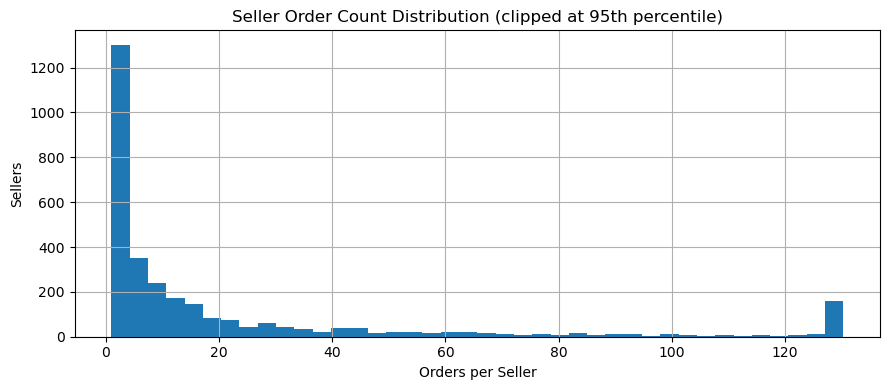

In [44]:
plt.figure(figsize=(9, 4))
seller_profile["orders"].clip(upper=seller_profile["orders"].quantile(.95)).hist(bins=40)
plt.title("Seller Order Count Distribution (clipped at 95th percentile)")
plt.xlabel("Orders per Seller")
plt.ylabel("Sellers")
plt.tight_layout()
plt.show()

## 13. Commercial value versus customer experience

This is the center of Asher's current seller-management idea.

We ask whether high-sales sellers also provide strong customer outcomes, or whether commercial value and customer experience represent separate dimensions that Olist may need to balance.

Because averages are unstable for sellers with only one or two orders, the main comparisons below use a minimum order threshold.

In [46]:
MIN_SELLER_ORDERS = 10

established_sellers = seller_profile[
    seller_profile["orders"] >= MIN_SELLER_ORDERS
].copy()

print("Sellers with at least", MIN_SELLER_ORDERS, "orders:", len(established_sellers))

corr_cols = [
    "orders", "sales_value", "avg_order_value", "avg_review",
    "low_review_rate", "five_star_rate", "late_delivery_rate",
    "seller_deadline_miss_rate", "avg_delivery_days"
]
established_sellers[corr_cols].corr(numeric_only=True).round(3)

Sellers with at least 10 orders: 1271


,orders,sales_value,avg_order_value,avg_review,low_review_rate,five_star_rate,late_delivery_rate,seller_deadline_miss_rate,avg_delivery_days
orders,1.000,0.779,-0.077,-0.022,0.007,-0.045,0.000,-0.038,0.043
sales_value,0.779,1.000,0.230,-0.022,0.015,-0.030,0.017,-0.024,0.099
avg_order_value,-0.077,0.230,1.000,-0.075,0.086,-0.037,0.069,0.049,0.154
avg_review,-0.022,-0.022,-0.075,1.000,-0.944,0.869,-0.485,-0.453,-0.497
low_review_rate,0.007,0.015,0.086,-0.944,1.000,-0.691,0.486,0.435,0.446
five_star_rate,-0.045,-0.030,-0.037,0.869,-0.691,1.000,-0.362,-0.366,-0.453
late_delivery_rate,0.000,0.017,0.069,-0.485,0.486,-0.362,1.000,0.397,0.554
seller_deadline_miss_rate,-0.038,-0.024,0.049,-0.453,0.435,-0.366,0.397,1.000,0.501
avg_delivery_days,0.043,0.099,0.154,-0.497,0.446,-0.453,0.554,0.501,1.000


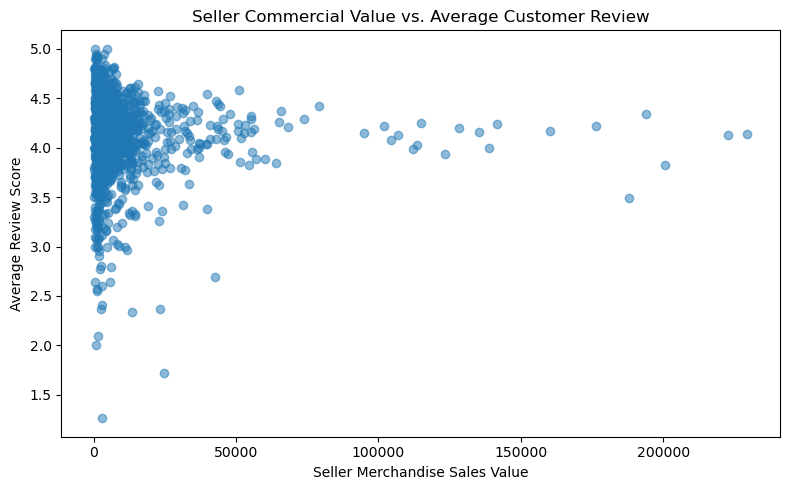

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(
    established_sellers["sales_value"],
    established_sellers["avg_review"],
    alpha=0.5
)
plt.title("Seller Commercial Value vs. Average Customer Review")
plt.xlabel("Seller Merchandise Sales Value")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

In [48]:
# Use medians only as an exploratory segmentation, NOT a final ranking rule.
sales_cut = established_sellers["sales_value"].median()
review_cut = established_sellers["avg_review"].median()

established_sellers["value_experience_segment"] = np.select(
    [
        (established_sellers["sales_value"] >= sales_cut) &
        (established_sellers["avg_review"] >= review_cut),

        (established_sellers["sales_value"] >= sales_cut) &
        (established_sellers["avg_review"] < review_cut),

        (established_sellers["sales_value"] < sales_cut) &
        (established_sellers["avg_review"] >= review_cut),
    ],
    [
        "High value / Strong experience",
        "High value / Weak experience",
        "Lower value / Strong experience"
    ],
    default="Lower value / Weak experience"
)

segment_summary = (
    established_sellers.groupby("value_experience_segment")
    .agg(
        sellers=("seller_id", "nunique"),
        avg_orders=("orders", "mean"),
        avg_sales=("sales_value", "mean"),
        avg_review=("avg_review", "mean"),
        late_rate=("late_delivery_rate", "mean"),
        deadline_miss_rate=("seller_deadline_miss_rate", "mean")
    )
    .sort_values("sellers", ascending=False)
)

segment_summary

,sellers,avg_orders,avg_sales,avg_review,late_rate,deadline_miss_rate
value_experience_segment,,,,,,
High value / Weak experience,340,141.318,"17,876.296",3.861,0.102,0.142
Lower value / Strong experience,340,21.803,"1,785.158",4.448,0.055,0.066
High value / Strong experience,296,107.108,"17,115.400",4.361,0.058,0.050
Lower value / Weak experience,295,22.898,"1,905.266",3.757,0.106,0.143


### Why this matters

This segmentation is **descriptive**, not the final model target.

It helps answer whether Olist faces different seller-management decisions:

- **High value / Strong experience:** candidates for retention, partnership, or growth support.
- **High value / Weak experience:** commercially important sellers that may warrant quality or fulfillment intervention.
- **Lower value / Strong experience:** possible growth opportunities if demand can be expanded.
- **Lower value / Weak experience:** lower priority unless there is strategic value not captured by the dataset.

The next question is whether historical seller behavior can predict future seller outcomes.

## 14. Seller performance persistence over time

In [51]:
# Split the order history chronologically at the 70th percentile of purchase time.
all_purchase_times = seller_order["order_purchase_timestamp"].dropna().sort_values()
split_date = all_purchase_times.quantile(0.70)
print("Chronological split date:", split_date)

hist_so = seller_order[seller_order["order_purchase_timestamp"] <= split_date].copy()
future_so = seller_order[seller_order["order_purchase_timestamp"] > split_date].copy()

def seller_period_summary(df, prefix):
    result = (
        df.groupby("seller_id")
        .agg(
            orders=("order_id", "nunique"),
            sales_value=("seller_merchandise_value", "sum"),
            avg_review=("mean_review_score", "mean"),
            low_review_rate=("last_review_score", lambda x: (x <= 2).mean()),
            late_delivery_rate=("late_delivery", "mean"),
            deadline_miss_rate=("seller_deadline_miss", "mean"),
            avg_order_value=("seller_merchandise_value", "mean")
        )
    )
    result.columns = [f"{prefix}_{c}" for c in result.columns]
    return result

hist_seller = seller_period_summary(hist_so, "hist")
future_seller = seller_period_summary(future_so, "future")

seller_time = hist_seller.join(future_seller, how="inner").reset_index()

print("Sellers appearing in both historical and future periods:", len(seller_time))
seller_time.head()

Chronological split date: 2018-04-15 15:14:18.700000
Sellers appearing in both historical and future periods: 1244


,seller_id,hist_orders,hist_sales_value,hist_avg_review,hist_low_review_rate,hist_late_delivery_rate,hist_deadline_miss_rate,hist_avg_order_value,future_orders,future_sales_value,future_avg_review,future_low_review_rate,future_late_delivery_rate,future_deadline_miss_rate,future_avg_order_value
0,001cca7ae9ae17fb1caed9dfb1094831,196,"24,580.130",3.984,0.158,0.068,0.061,125.409,4,499.900,4.000,0.250,0.000,0.000,124.975
1,004c9cd9d87a3c30c522c48c4fc07416,155,"19,258.210",4.138,0.129,0.085,0.000,124.247,3,454.500,4.667,0.000,0.000,0.000,151.500
2,00720abe85ba0859807595bbf045a33b,6,395.300,3.667,0.333,0.167,0.167,65.883,7,612.200,3.571,0.143,0.143,0.286,87.457
3,00ee68308b45bc5e2660cd833c3f81cc,121,"18,395.000",4.300,0.107,0.091,0.008,152.025,14,"1,865.000",4.286,0.143,0.071,0.000,133.214
4,00fc707aaaad2d31347cf883cd2dfe10,98,"12,024.600",4.067,0.163,0.041,0.000,122.700,5,660.300,4.000,0.000,0.200,0.000,132.060


In [52]:
# Require enough history so historical averages are meaningful.
seller_time_eligible = seller_time[
    (seller_time["hist_orders"] >= 5) &
    (seller_time["future_orders"] >= 3)
].copy()

print("Eligible sellers with >=5 historical and >=3 future orders:",
      len(seller_time_eligible))

persistence_cols = [
    "hist_orders", "hist_sales_value", "hist_avg_review",
    "hist_low_review_rate", "hist_late_delivery_rate",
    "hist_deadline_miss_rate",
    "future_orders", "future_sales_value", "future_avg_review",
    "future_low_review_rate", "future_late_delivery_rate",
    "future_deadline_miss_rate"
]

seller_time_eligible[persistence_cols].corr(numeric_only=True).loc[
    [
        "hist_orders", "hist_sales_value", "hist_avg_review",
        "hist_low_review_rate", "hist_late_delivery_rate",
        "hist_deadline_miss_rate"
    ],
    [
        "future_orders", "future_sales_value", "future_avg_review",
        "future_low_review_rate", "future_late_delivery_rate",
        "future_deadline_miss_rate"
    ]
].round(3)

Eligible sellers with >=5 historical and >=3 future orders: 765


,future_orders,future_sales_value,future_avg_review,future_low_review_rate,future_late_delivery_rate,future_deadline_miss_rate
hist_orders,0.668,0.479,-0.007,-0.004,-0.008,-0.039
hist_sales_value,0.507,0.600,-0.008,0.011,-0.001,-0.022
hist_avg_review,-0.031,-0.016,0.240,-0.227,-0.087,-0.208
hist_low_review_rate,0.014,0.007,-0.239,0.223,0.092,0.223
hist_late_delivery_rate,0.047,0.063,-0.113,0.134,0.085,0.158
hist_deadline_miss_rate,-0.003,-0.007,-0.283,0.269,0.180,0.397


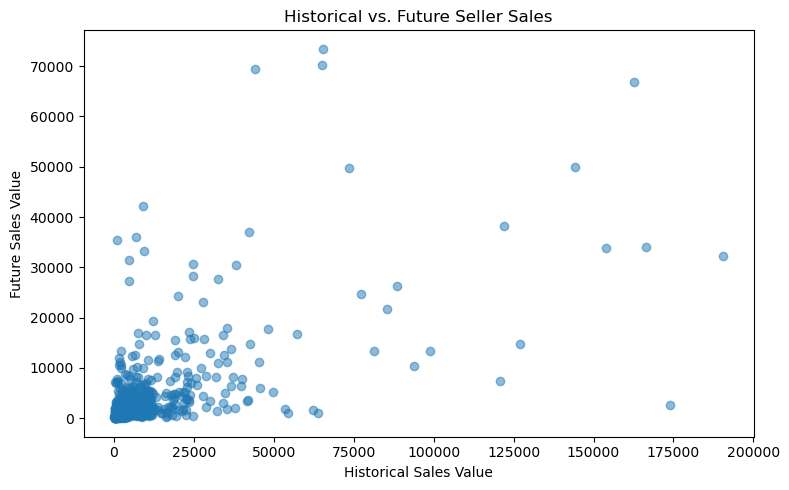

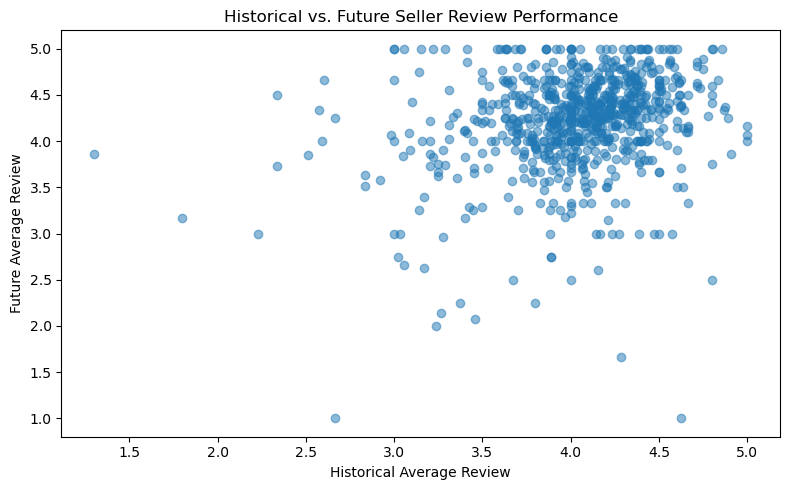

In [53]:
plt.figure(figsize=(8, 5))
plt.scatter(
    seller_time_eligible["hist_sales_value"],
    seller_time_eligible["future_sales_value"],
    alpha=0.5
)
plt.title("Historical vs. Future Seller Sales")
plt.xlabel("Historical Sales Value")
plt.ylabel("Future Sales Value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    seller_time_eligible["hist_avg_review"],
    seller_time_eligible["future_avg_review"],
    alpha=0.5
)
plt.title("Historical vs. Future Seller Review Performance")
plt.xlabel("Historical Average Review")
plt.ylabel("Future Average Review")
plt.tight_layout()
plt.show()

## 15. Candidate future seller-prioritization target

We should **not finalize a ranking target yet**, but we can test whether a future-oriented seller target is feasible.

A possible structure would be:

> Based only on a seller's historical marketplace performance, identify sellers that are likely to provide both strong future commercial value and strong future customer experience.

Below we create an **exploratory candidate label** using future-period medians. This is not a final business definition. It is only a feasibility check.

In [55]:
if len(seller_time_eligible) > 0:
    future_sales_cut = seller_time_eligible["future_sales_value"].median()
    future_review_cut = seller_time_eligible["future_avg_review"].median()

    seller_time_eligible["future_high_value_good_experience"] = (
        (seller_time_eligible["future_sales_value"] >= future_sales_cut) &
        (seller_time_eligible["future_avg_review"] >= future_review_cut)
    ).astype(int)

    print("Future sales median:", round(future_sales_cut, 2))
    print("Future review median:", round(future_review_cut, 3))
    print("Candidate positive rate:",
          f"{seller_time_eligible['future_high_value_good_experience'].mean():.2%}")

    display(
        seller_time_eligible[
            ["future_sales_value", "future_avg_review",
             "future_high_value_good_experience"]
        ].describe()
    )

Future sales median: 1526.0
Future review median: 4.281
Candidate positive rate: 24.71%


,future_sales_value,future_avg_review,future_high_value_good_experience
count,765.000,765.000,765.000
mean,"3,870.545",4.218,0.247
std,"7,779.049",0.529,0.432
min,2.550,1.000,0.000
25%,651.000,4.000,0.000
50%,"1,526.000",4.281,0.000
75%,"3,417.520",4.562,0.000
max,"73,431.160",5.000,1.000


### Feasibility interpretation

This target would support a controllable marketplace decision more directly than predicting individual carrier delivery outcomes.

Possible stakeholder action:

- prioritize seller success resources,
- identify high-potential sellers for partnership or growth programs,
- identify high-value sellers whose customer experience requires attention,
- decide where marketplace account-management effort may have the greatest value.

Before modeling, the team still needs to agree on:

1. the exact stakeholder,
2. the resource or decision being allocated,
3. the definition of "strong commercial value,"
4. the definition of "strong customer experience,"
5. the minimum historical activity needed before scoring a seller.

## 16. Seller geography and seller-customer distance

In [58]:
# Aggregate geolocation to one centroid per zip prefix to avoid duplicate geolocation rows.
geo_zip = (
    geolocation.groupby("geolocation_zip_code_prefix")
    .agg(
        lat=("geolocation_lat", "median"),
        lng=("geolocation_lng", "median")
    )
    .reset_index()
)

seller_geo = sellers.merge(
    geo_zip,
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
).rename(columns={"lat": "seller_lat", "lng": "seller_lng"})

customer_geo = customers.merge(
    geo_zip,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
).rename(columns={"lat": "customer_lat", "lng": "customer_lng"})

order_geo = (
    orders_dt[["order_id", "customer_id"]]
    .merge(
        customer_geo[["customer_id", "customer_lat", "customer_lng"]],
        on="customer_id", how="left"
    )
)

seller_order_geo = (
    seller_order
    .merge(order_geo, on="order_id", how="left")
    .merge(
        seller_geo[["seller_id", "seller_lat", "seller_lng"]],
        on="seller_id", how="left"
    )
)

def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * r * np.arcsin(np.sqrt(a))

seller_order_geo["seller_customer_distance_km"] = haversine_km(
    seller_order_geo["seller_lat"],
    seller_order_geo["seller_lng"],
    seller_order_geo["customer_lat"],
    seller_order_geo["customer_lng"]
)

seller_order_geo["seller_customer_distance_km"].describe()

count   99,511.000
mean       601.051
std        594.495
min          0.000
25%        186.367
50%        433.760
75%        798.585
max      8,677.860
Name: seller_customer_distance_km, dtype: float64

In [59]:
distance_valid = seller_order_geo.dropna(
    subset=["seller_customer_distance_km", "late_delivery"]
).copy()

distance_valid["distance_band"] = pd.qcut(
    distance_valid["seller_customer_distance_km"],
    q=5,
    duplicates="drop"
)

distance_summary = (
    distance_valid.groupby("distance_band", observed=False)
    .agg(
        seller_orders=("order_id", "size"),
        avg_distance_km=("seller_customer_distance_km", "mean"),
        late_rate=("late_delivery", "mean"),
        avg_freight=("seller_freight_value", "mean"),
        avg_review=("mean_review_score", "mean")
    )
)

distance_summary

,seller_orders,avg_distance_km,late_rate,avg_freight,avg_review
distance_band,,,,,
"(-0.001, 116.765]",19467,44.830,0.064,13.496,4.260
"(116.765, 347.977]",19466,253.808,0.067,19.658,4.171
"(347.977, 529.691]",19466,433.320,0.075,22.210,4.137
"(529.691, 875.961]",19466,696.650,0.085,23.956,4.088
"(875.961, 8677.86]",19466,"1,572.274",0.109,33.012,4.032


## 17. Seller category specialization and portfolio breadth

In [61]:
seller_category = (
    product_items.groupby(["seller_id", "product_category_name_english"], dropna=False)
    .agg(
        item_lines=("order_item_id", "count"),
        sales_value=("price", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

seller_category_breadth = (
    seller_category.groupby("seller_id")
    .agg(
        categories_sold=("product_category_name_english", "nunique"),
        largest_category_share=(
            "sales_value",
            lambda x: x.max() / x.sum() if x.sum() else np.nan
        )
    )
    .reset_index()
)

seller_profile2 = seller_profile.merge(
    seller_category_breadth,
    on="seller_id",
    how="left"
)

seller_profile2[[
    "orders", "sales_value", "avg_review",
    "categories_sold", "largest_category_share"
]].corr(numeric_only=True).round(3)

,orders,sales_value,avg_review,categories_sold,largest_category_share
orders,1.000,0.800,0.029,0.379,-0.128
sales_value,0.800,1.000,0.025,0.318,-0.094
avg_review,0.029,0.025,1.000,0.044,-0.046
categories_sold,0.379,0.318,0.044,1.000,-0.675
largest_category_share,-0.128,-0.094,-0.046,-0.675,1.000


## 18. Seller concentration and marketplace dependence

In [63]:
seller_sales_rank = seller_profile.sort_values("sales_value", ascending=False).copy()
seller_sales_rank["sales_share"] = (
    seller_sales_rank["sales_value"] / seller_sales_rank["sales_value"].sum()
)
seller_sales_rank["cumulative_sales_share"] = seller_sales_rank["sales_share"].cumsum()

concentration = pd.Series({
    "top_10_seller_sales_share": seller_sales_rank.head(10)["sales_share"].sum(),
    "top_50_seller_sales_share": seller_sales_rank.head(50)["sales_share"].sum(),
    "top_100_seller_sales_share": seller_sales_rank.head(100)["sales_share"].sum(),
})
concentration

top_10_seller_sales_share    0.131
top_50_seller_sales_share    0.329
top_100_seller_sales_share   0.451
dtype: float64

## 19. Time trends and marketplace growth

In [65]:
monthly = (
    order_analysis.dropna(subset=["order_purchase_timestamp"])
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(
        orders=("order_id", "nunique"),
        merchandise_value=("merchandise_value", "sum"),
        avg_review=("mean_review_score", "mean"),
        late_rate=("late_delivery", "mean"),
        unique_customers=("customer_unique_id", "nunique")
    )
)

monthly.tail(18)

,orders,merchandise_value,avg_review,late_rate,unique_customers
order_purchase_timestamp,,,,,
2017-05-01,3700,"506,071.140",4.142,0.036,3625
2017-06-01,3245,"433,038.600",4.148,0.039,3180
2017-07-01,4026,"498,031.480",4.175,0.034,3947
2017-08-01,4331,"573,971.680",4.237,0.033,4246
2017-09-01,4285,"624,401.690",4.188,0.052,4212
2017-10-01,4631,"664,219.430",4.125,0.053,4561
2017-11-01,7544,"1,010,271.370",3.911,0.143,7430
2017-12-01,5673,"743,914.170",4.019,0.084,5603
2018-01-01,7269,"950,030.360",4.042,0.066,7166


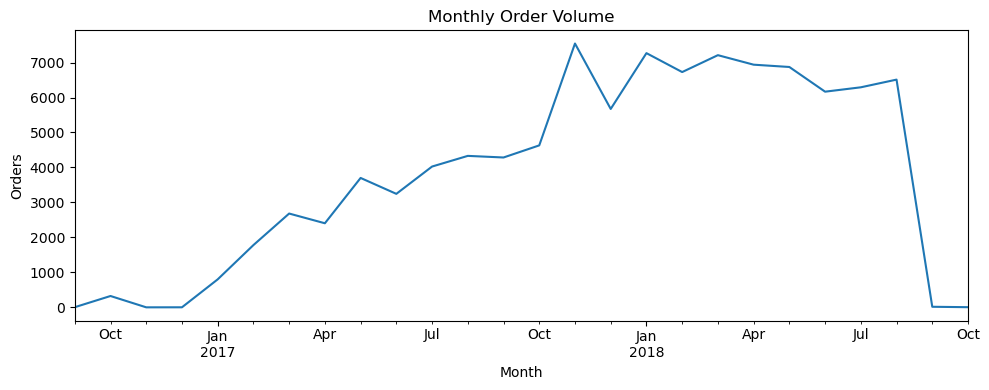

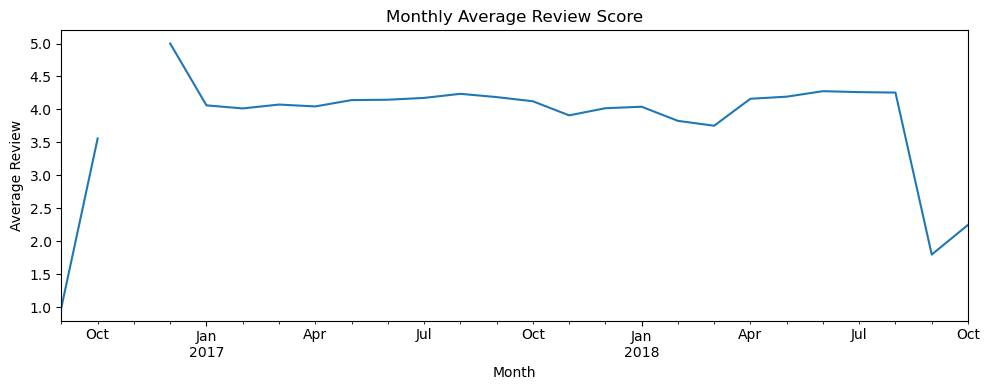

In [66]:
plt.figure(figsize=(10, 4))
monthly["orders"].plot()
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
monthly["avg_review"].plot()
plt.title("Monthly Average Review Score")
plt.xlabel("Month")
plt.ylabel("Average Review")
plt.tight_layout()
plt.show()